# Gaussian Mixture Models with `mclust`

## Overview

Gaussian Mixture Models (GMMs) model the data as a weighted sum of k Gaussian distributions. Unlike k-means, they produce **soft assignments** — each observation has a probability of belonging to each cluster — and allow clusters of different shapes, sizes, and orientations.

**GMM vs. k-means:**

| Feature | k-Means | GMM |
|---|---|---|
| Assignment | Hard (one cluster) | Soft (probabilities) |
| Cluster shape | Spherical only | Elliptical (all orientations) |
| Cluster size | Equal assumed | Variable |
| Model selection | Elbow / silhouette | BIC (automatic) |
| Probabilistic | No | Yes |

**`mclust` model notation:** Models are parameterised by three properties:
- **Volume (E/V):** Equal or Variable cluster volume
- **Shape (E/V):** Equal or Variable cluster shape
- **Orientation (I/E/V):** Identity, Equal, or Variable cluster orientation

e.g. `EEE` = equal volume, shape, orientation (spherical clusters); `VVV` = fully flexible.

`mclust` automatically selects both k and the covariance model by maximising BIC.

---

## Setup

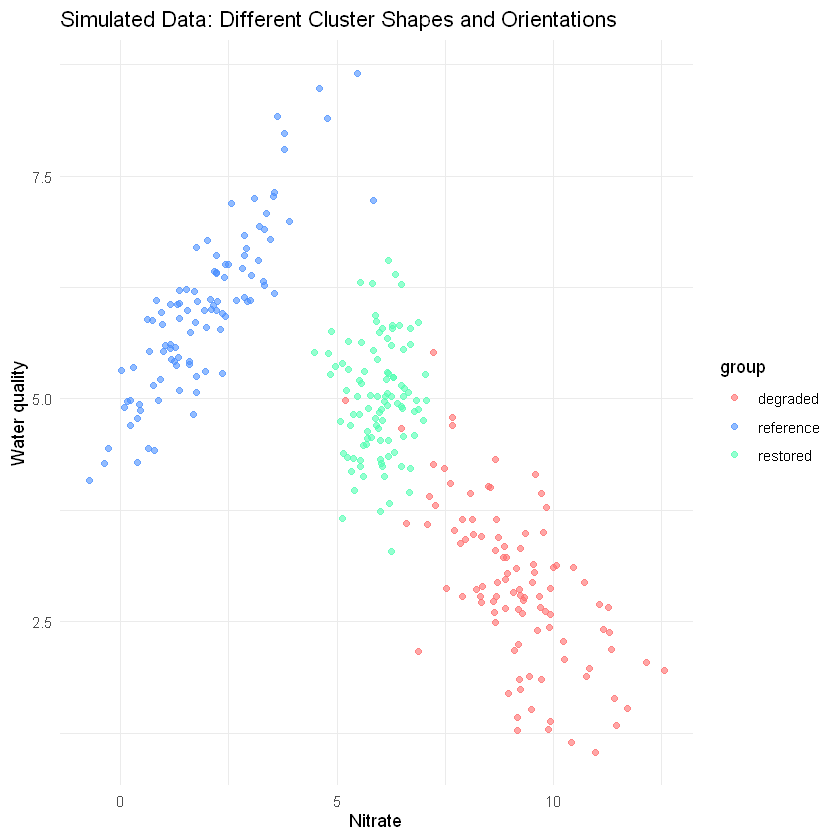

In [3]:
library(tidyverse)
library(ggplot2)
library(mclust)
library(patchwork)

set.seed(42)

# ── Simulate: clusters with different shapes and orientations ─────────────────
n_per <- 100

MASS_mvrnorm <- function(n, mu, Sigma) {
  MASS::mvrnorm(n = n, mu = mu, Sigma = Sigma)
}

gmm_data <- bind_rows(
  # Cluster 1: elongated, NE orientation
  # det = 1.5*0.8 - 0.9*0.9 = 1.2 - 0.81 = 0.39 > 0 ✓
  as_tibble(MASS_mvrnorm(n_per, c(2, 6), matrix(c(1.5, 0.9, 0.9, 0.8), 2))) %>%
    setNames(c("nitrate", "water_qual")) %>% mutate(group = "reference"),
  # Cluster 2: small, spherical
  as_tibble(MASS_mvrnorm(n_per, c(6, 5), matrix(c(0.4, 0, 0, 0.4), 2))) %>%
    setNames(c("nitrate", "water_qual")) %>% mutate(group = "restored"),
  # Cluster 3: large, elongated, NW orientation
  # det = 1.5*0.9 - 0.8*0.8 = 1.35 - 0.64 = 0.71 > 0 ✓
  as_tibble(MASS_mvrnorm(n_per, c(9, 3), matrix(c(1.5, -0.8, -0.8, 0.9), 2))) %>%
    setNames(c("nitrate", "water_qual")) %>% mutate(group = "degraded")
)

X <- dplyr::select(gmm_data, nitrate, water_qual) %>% as.matrix()

ggplot(gmm_data, aes(x = nitrate, y = water_qual, color = group)) +
  geom_point(alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c(reference = "#4a8fff", restored = "#4fffb0",
                                degraded  = "#ff6b6b")) +
  labs(title = "Simulated Data: Different Cluster Shapes and Orientations",
       x = "Nitrate", y = "Water quality") +
  theme_minimal()

---

## Fit GMM with Automatic Model Selection

Selected model: VVV
Selected k:     3
BIC:            -2078.9


---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VVV (ellipsoidal, varying volume, shape, and orientation) model with 3
components: 

 log-likelihood   n df       BIC       ICL
      -990.9755 300 17 -2078.915 -2090.074

Clustering table:
  1   2   3 
 99 105  96 

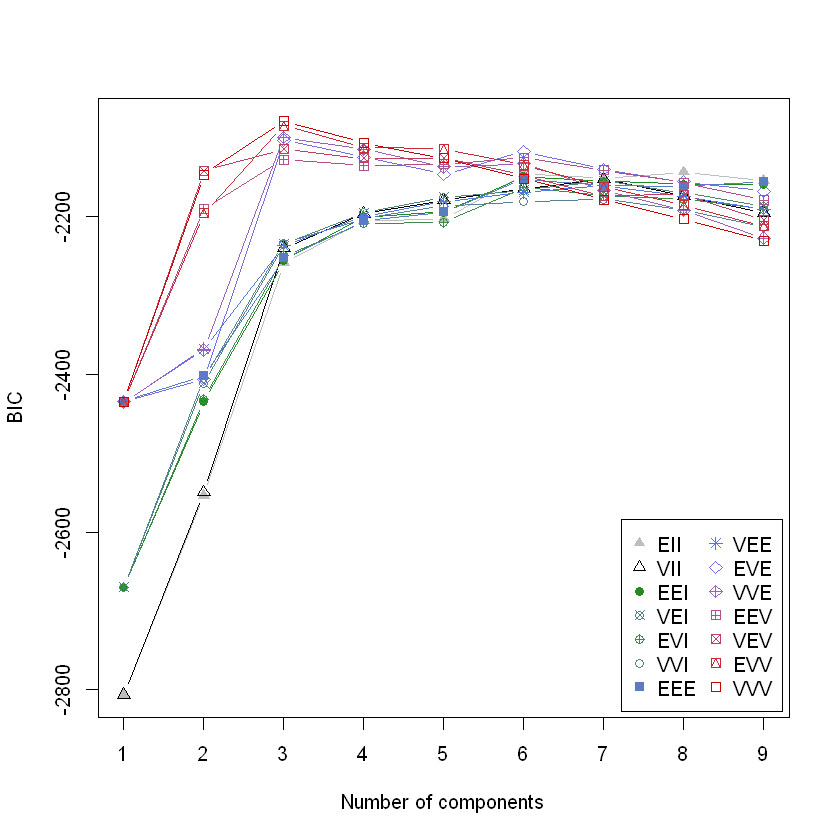

In [4]:
# Mclust fits all combinations of covariance models and k=1..9
# Selects the best by BIC (higher = better in mclust's convention)
gmm_fit <- mclust::Mclust(X, G=1:9)

cat(sprintf("Selected model: %s\n",  gmm_fit$modelName))
cat(sprintf("Selected k:     %d\n",  gmm_fit$G))
cat(sprintf("BIC:            %.1f\n", gmm_fit$bic))

# ── BIC plot across all models ────────────────────────────────────────────────
plot(gmm_fit, what="BIC")
# Each line = one covariance model; each point = one k
# Model with highest BIC (top right) is selected

# ── Cluster summary ───────────────────────────────────────────────────────────
summary(gmm_fit)

---

## Soft Assignments and Uncertainty


Mean uncertainty: 0.0164
Observations >10% uncertainty: 14 (4.7%)


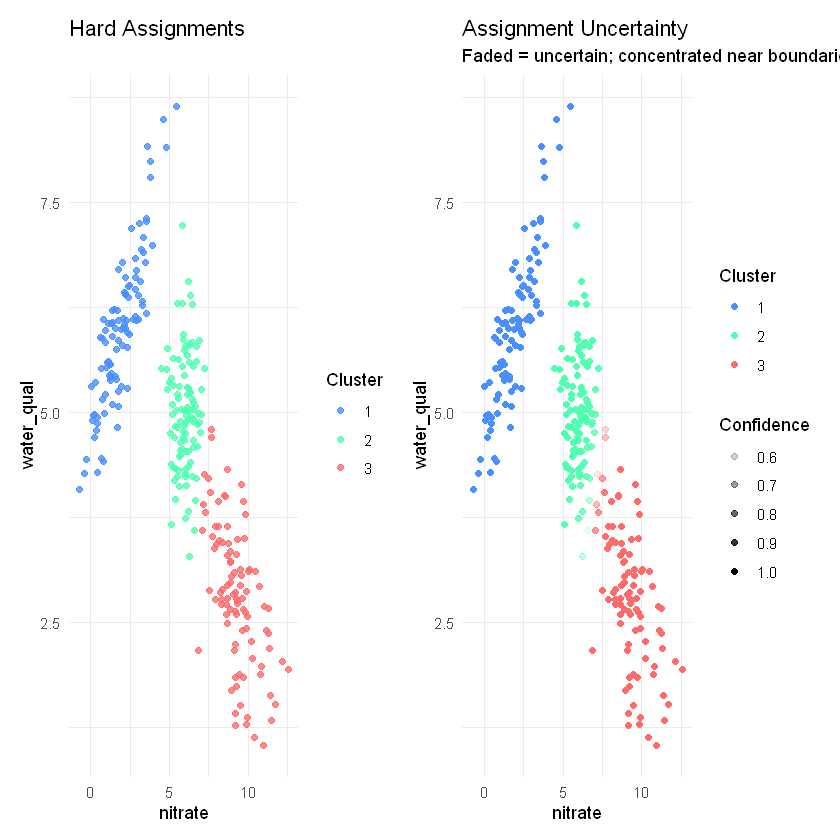

In [5]:
# ── Classification: hard assignments ─────────────────────────────────────────
hard_clusters <- gmm_fit$classification

# ── Probabilities: soft assignments ──────────────────────────────────────────
probs <- gmm_fit$z   # n × k matrix of cluster membership probabilities

# Uncertainty: 1 - max probability (how confident is the assignment?)
uncertainty <- apply(probs, 1, function(p) 1 - max(p))

results <- gmm_data %>%
  mutate(
    cluster     = factor(hard_clusters),
    uncertainty = uncertainty
  )

# Plot: uncertainty as point transparency
p_hard <- ggplot(results, aes(x=nitrate, y=water_qual, color=cluster)) +
  geom_point(size=1.5, alpha=0.8) +
  scale_color_manual(values=c("#4a8fff","#4fffb0","#ff6b6b")) +
  labs(title="Hard Assignments", color="Cluster") + theme_minimal()

p_uncert <- ggplot(results, aes(x=nitrate, y=water_qual,
                                 color=cluster, alpha=1-uncertainty)) +
  geom_point(size=1.5) +
  scale_color_manual(values=c("#4a8fff","#4fffb0","#ff6b6b")) +
  scale_alpha_continuous(range=c(0.15, 1), name="Confidence") +
  labs(title="Assignment Uncertainty",
       subtitle="Faded = uncertain; concentrated near boundaries",
       color="Cluster") + theme_minimal()

(p_hard | p_uncert)

cat(sprintf("\nMean uncertainty: %.4f\n", mean(uncertainty)))
cat(sprintf("Observations >10%% uncertainty: %d (%.1f%%)\n",
            sum(uncertainty>0.1), mean(uncertainty>0.1)*100))

---

## Density Estimation and Classification Boundaries

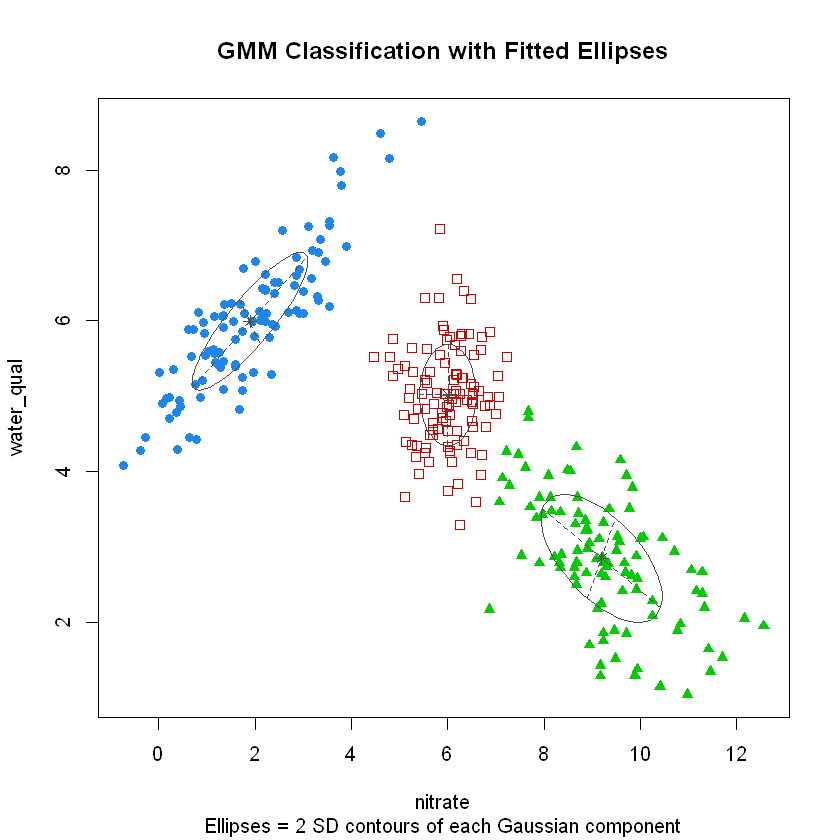


Contingency table (GMM cluster vs. true group):
   true
GMM degraded reference restored
  1        0        99        0
  2        4         1      100
  3       96         0        0
Adjusted Rand Index: 0.9503


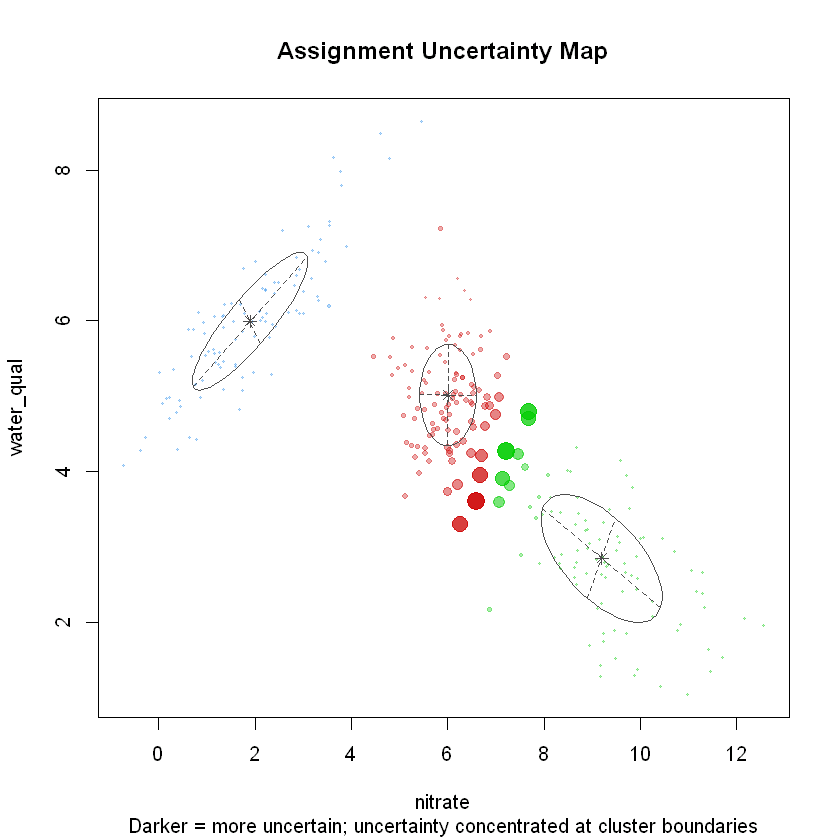

In [6]:
# Plot the fitted GMM density contours
plot(gmm_fit, what="classification")
title("GMM Classification with Fitted Ellipses",
      sub="Ellipses = 2 SD contours of each Gaussian component")

# Uncertainty plot (mclust built-in)
plot(gmm_fit, what="uncertainty")
title("Assignment Uncertainty Map",
      sub="Darker = more uncertain; uncertainty concentrated at cluster boundaries")

# Agreement with true groups
cat("\nContingency table (GMM cluster vs. true group):\n")
print(table(GMM=results$cluster, true=gmm_data$group))

# Adjusted Rand Index: 1 = perfect agreement, 0 = random
ari <- mclust::adjustedRandIndex(gmm_fit$classification, gmm_data$group)
cat(sprintf("Adjusted Rand Index: %.4f\n", ari))

---

## Common Pitfalls

**1. Assuming BIC always selects the correct number of clusters**  
BIC selects the model that best balances fit and complexity given the Gaussian assumption. If the true clusters are non-Gaussian (e.g. skewed, multimodal within cluster), BIC may select more components than expected to approximate the non-Gaussian shape. Always validate the selected k with domain knowledge and silhouette scores.

**2. Not examining the uncertainty of assignments**  
GMMs produce soft assignments, but analysts often use only the hard classifications. Observations with high uncertainty (near cluster boundaries) should be flagged — they may represent genuinely intermediate cases, transitional states, or poor model fit in that region.

**3. Using GMMs with non-Gaussian features without transformation**  
GMMs assume multivariate normality within each cluster. Highly skewed features (e.g. concentrations, counts) should be log-transformed before fitting. Check within-cluster normality after fitting using Q-Q plots on each component.

**4. Over-interpreting the covariance model selected by BIC**  
The selected model (e.g. `VVV` = unconstrained) reflects the BIC-optimal representation of the data, not necessarily the true data-generating process. Models within 2 BIC units of the best are plausible alternatives — check whether cluster assignments are similar across competitive models.

**5. Ignoring cluster degeneracy warnings**  
A degenerate solution occurs when a cluster collapses to a single point (zero variance). This produces infinite likelihood and invalid results. If `mclust` reports a degenerate solution for some k values, reduce the maximum k or inspect the data for near-duplicate observations.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*